We can now rename column name to make it more standard for ease of coding and readability.

In [47]:
iris_data.rename(columns={'sepal length (cm)':'sepal_length',
                          'sepal width (cm)':'sepal_width',
                          'petal length (cm)':'petal_length',
                          'petal width (cm)':'petal_width'},inplace=True)

Add a new column named "species" having value {if target == 0 : 'setosa' ,
if target ==1 : 'versicolor',
if target == 2 : 'virginica' }

In [69]:
#your code here
iris_data['species']=iris_data['target'].map({0:'setosa',1:'versicolor',2:'virginica'})

we will now select "versicolor" to predict its "petal_width" using "petal_length " as one of the parameter.So your next task is to make a new DataFrame named "data" having only rows whose species values are 'versicolor'.


In [70]:
#your code here
print(iris_data.dtypes)
def change_dataframe(iris_data):
    #cond1=(iris_data['species']=='versicolor')
    cond1=(iris_data['target']==1)
    return iris_data[cond1]
data=change_dataframe(iris_data)

data.head()



species          object
species          object
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
target            int64
dtype: object


,species,species,sepal_length,sepal_width,petal_length,petal_width,target
50,versicolor,versicolor,7.0,3.2,4.7,1.4,1
51,versicolor,versicolor,6.4,3.2,4.5,1.5,1
52,versicolor,versicolor,6.9,3.1,4.9,1.5,1
53,versicolor,versicolor,5.5,2.3,4.0,1.3,1
54,versicolor,versicolor,6.5,2.8,4.6,1.5,1


Now we are droping  all the columns except petal_length and petal_width

In [71]:
data.drop(columns=['target','species','sepal_length','sepal_width'],inplace=True)
data.head()

C:\Users\Yash Tripathi\AppData\Local\Temp\ipykernel_24292\220937503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['target','species','sepal_length','sepal_width'],inplace=True)


,petal_length,petal_width
50,4.7,1.4
51,4.5,1.5
52,4.9,1.5
53,4.0,1.3
54,4.6,1.5


Now write code to print the shape of DataFrame named as data.

In [72]:
#your code here
data.shape

(50, 2)

Now  plot the Dataframe named data having x axis as 'petal_length', y axis as 'petal_width' and kind='scatter'

<Axes: xlabel='petal length', ylabel='petal width'>

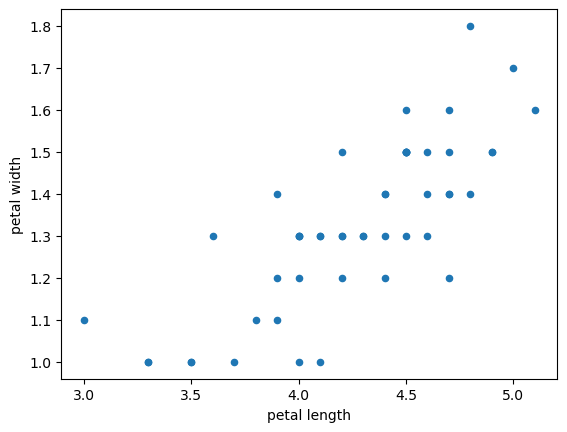

In [85]:
#your code here
data.plot(xlabel='petal length',ylabel='petal width',x='petal_length',y='petal_width',kind='scatter')


Now let's start with Linear Regression

We will now split the dataset into training and test datasets into (X_train,Y_train) and (X_test,Y_test)

In [86]:
from sklearn.model_selection import train_test_split
X=data['petal_length'].values.reshape(-1,1)
Y=data['petal_width'].values.reshape(-1,1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.33,random_state=1)


Now let's plot the training  datasets of  kind scatter with x axis as X_train and y axis as Y_train.

Text(0.5, 1.0, 'Training plot')

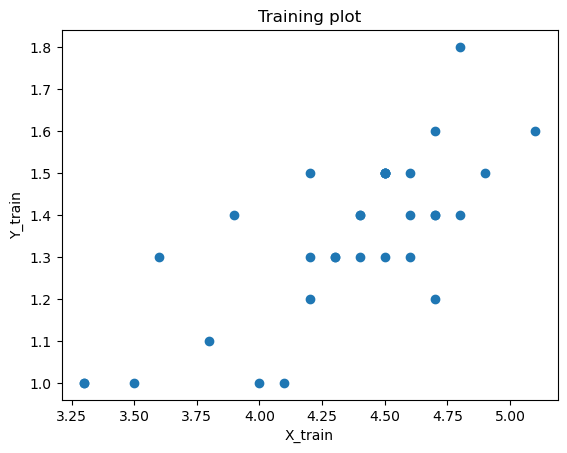

In [91]:
#your code here for plotting training dataset
pyplot.scatter(X_train,Y_train)
pyplot.xlabel('X_train')
pyplot.ylabel('Y_train')
pyplot.title('Training plot')

Now let's plot the test datasets of kind scatter with x axis as X_test and y axis as Y_test

Text(0.5, 1.0, 'Testing plot')

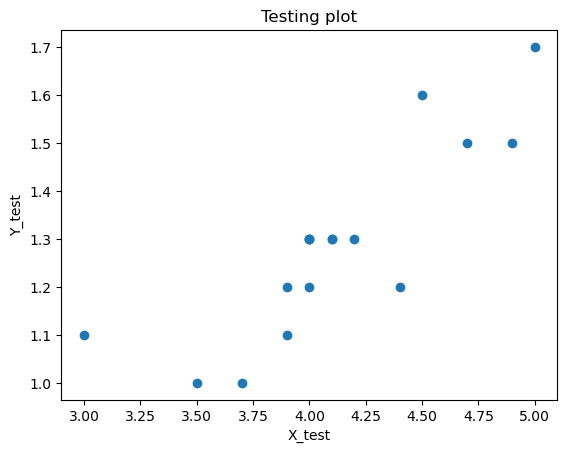

In [92]:
#your code here for plotting test dataset
pyplot.scatter(X_test,Y_test)
pyplot.xlabel('X_test')
pyplot.ylabel('Y_test')
pyplot.title('Testing plot')

Now write the code for LinearRegession using any preffered method.

In [93]:
#your code here
from sklearn import linear_model
reg=linear_model.LinearRegression()
reg.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now print the Intercept and Coefficient.

In [99]:
#your code here
intercept=reg.intercept_
slope=reg.coef_
print(slope)
print(intercept)

[[0.3338594]]
[-0.10228121]


Now we can overlay the predicted line and test data points to see where the predicted point lies.

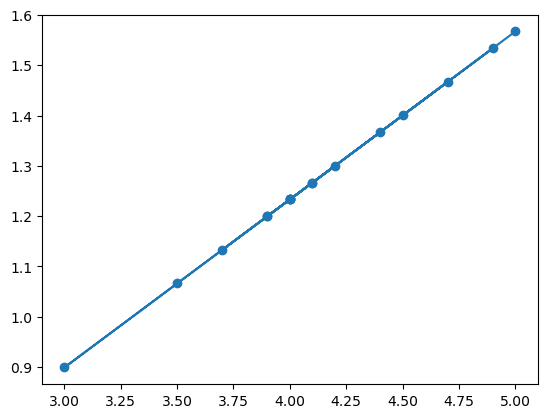

In [100]:
#your code here
Y_predict=reg.predict(X_test)
pyplot.scatter(X_test,Y_predict)
pyplot.plot(X_test,Y_predict)


### Lasso Regression

Let's implement Lasso Regression, which is a type of linear regression that uses shrinkage. Shrinkage is where data values are shrunk towards a central point as the mean. The Lasso method encourages simple models (i.e., models with fewer parameters), in some cases completely eliminating the effect of some features. It's often used for feature selection and to prevent overfitting.

In [116]:
# Import Lasso from sklearn
# Create a Lasso regressor object with an alpha (regularization strength) value
# Fit the model to the training data
#your code here
from sklearn import linear_model
Lasso_reg=linear_model.Lasso(alpha=0.00001)
Lasso_reg.fit(X_train, Y_train)


,alpha,1e-05
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [117]:
# Print the Intercept and Coefficient for Lasso Regression
#your code here
intercept=Lasso_reg.intercept_
slope=Lasso_reg.coef_
print(intercept)
print(slope)

[-0.10205537]
[0.33380732]


matplotlib.ticker.IndexLocator

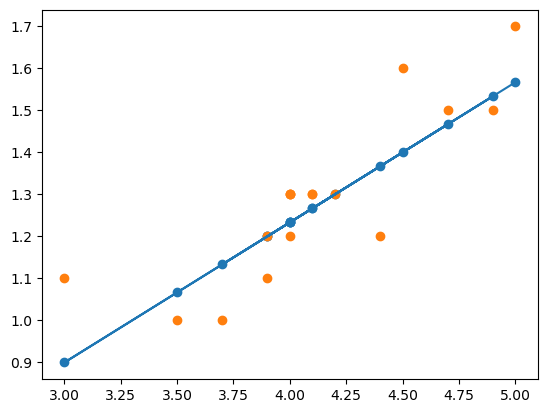

In [ ]:
# Predict on the test data
# Plot the test data points and the predicted line for Lasso Regression
#your code 9here
Y_predict=Lasso_reg.predict(X_test)
pyplot.scatter(X_test, Y_predict)
pyplot.plot(X_test,Y_predict)
pyplot.scatter(X_test,Y_test)


### Ridge Regression

Next, let's explore Ridge Regression. Like Lasso, Ridge Regression is also a regularization technique used to prevent overfitting, but it penalizes the sum of the squares of the coefficients. This tends to shrink the coefficients towards zero but doesn't set them exactly to zero, meaning it keeps all features in the model, unlike Lasso which can perform feature selection.

In [122]:
# Import Ridge from sklearn
# Create a Ridge regressor object with an alpha (regularization strength) value
# Fit the model to the training data
#your code here
from sklearn import linear_model
Ridge_reg=linear_model.Ridge(alpha=0.0001)
Ridge_reg.fit(X_train,Y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [123]:
# Print the Intercept and Coefficient for Ridge Regression
#your code here
intercept=Ridge_reg.intercept_
slope=Ridge_reg.coef_
print(intercept)
print(slope)

[-0.10225836]
[0.33385413]


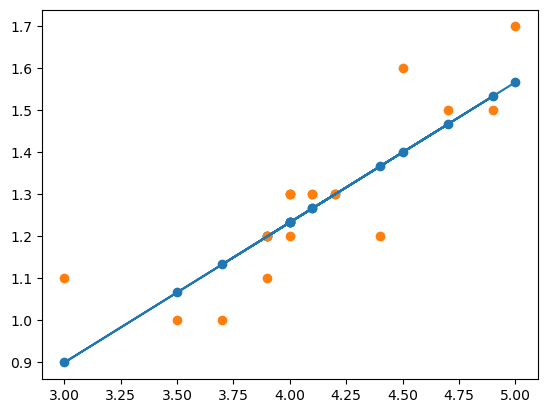

In [127]:
# Predict on the test data
# Plot the test data points and the predicted line for Ridge Regression
#your code here
Y_predict=Ridge_reg.predict(X_test)
pyplot.scatter(X_test,Y_predict)
pyplot.plot(X_test,Y_predict)
pyplot.scatter(X_test,Y_test)


This is end of assisgnment , but for futhur reading you can search articles on Multivariate Regression , ElasticNet regression and Stepwise Regression.